In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/full-filled-brain-stroke-dataset/full_data.csv
/kaggle/input/full-filled-brain-stroke-dataset/full_filled_stroke_data (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [4]:
df = pd.read_csv("/kaggle/input/full-filled-brain-stroke-dataset/full_filled_stroke_data (1).csv")

df.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1


In [7]:
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [8]:
print(df.isna().sum())

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [9]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [10]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (201, 11) 

number of rows:  201
number of columns:  11


In [11]:
df.describe(include='all')

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,201,201.000000,201.000000,201.000000,201,201,201,201.000000,201.000000,201,201.000000
unique,2,NaN,NaN,NaN,2,4,2,NaN,NaN,4,NaN
top,Male,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,Unknown,NaN
freq,104,NaN,NaN,NaN,149,114,106,NaN,NaN,61,NaN
mean,NaN,52.049154,0.233831,0.164179,NaN,NaN,NaN,126.724627,29.336870,NaN,0.199005
std,NaN,22.276181,0.424323,0.371363,NaN,NaN,NaN,59.240322,3.363098,NaN,0.400249
min,NaN,0.480000,0.000000,0.000000,NaN,NaN,NaN,57.520000,17.899295,NaN,0.000000
25%,NaN,37.000000,0.000000,0.000000,NaN,NaN,NaN,81.430000,28.397893,NaN,0.000000
50%,NaN,58.000000,0.000000,0.000000,NaN,NaN,NaN,99.870000,29.948147,NaN,0.000000
75%,NaN,71.000000,0.000000,0.000000,NaN,NaN,NaN,191.790000,31.378534,NaN,0.000000


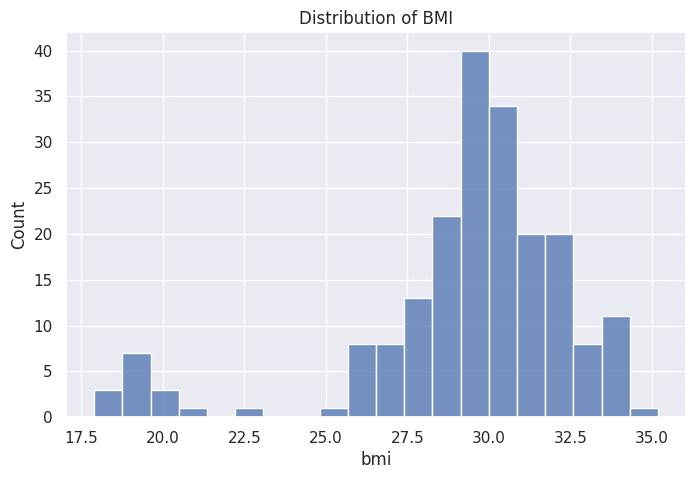

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20)
plt.title("Distribution of BMI")
plt.show()

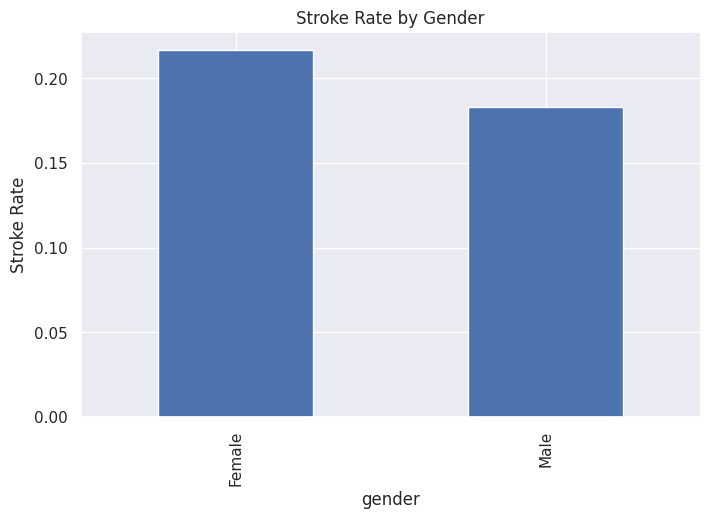

gender
Female    0.216495
Male      0.182692
Name: stroke, dtype: float64

In [28]:
stroke_gender = df.groupby('gender')['stroke'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
stroke_gender.plot(kind='bar')
plt.title("Stroke Rate by Gender")
plt.ylabel("Stroke Rate")
plt.show()

stroke_gender

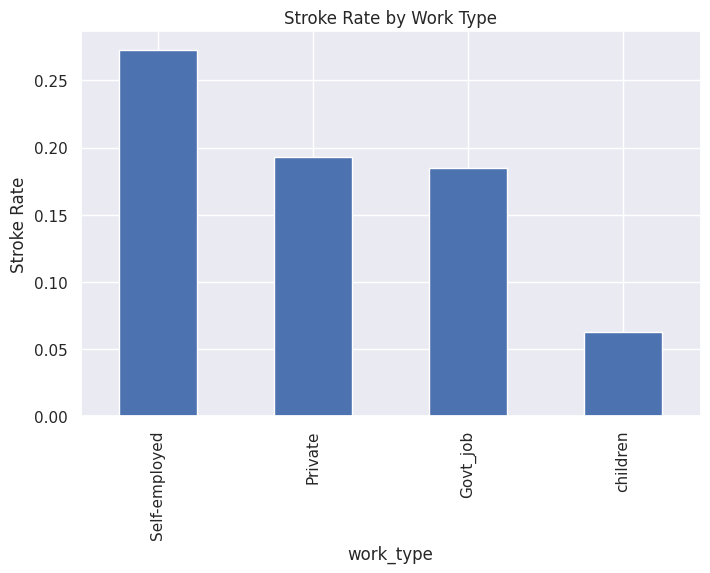

work_type
Self-employed    0.272727
Private          0.192982
Govt_job         0.185185
children         0.062500
Name: stroke, dtype: float64

In [29]:
stroke_work = df.groupby('work_type')['stroke'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
stroke_work.plot(kind='bar')
plt.title("Stroke Rate by Work Type")
plt.ylabel("Stroke Rate")
plt.show()

stroke_work

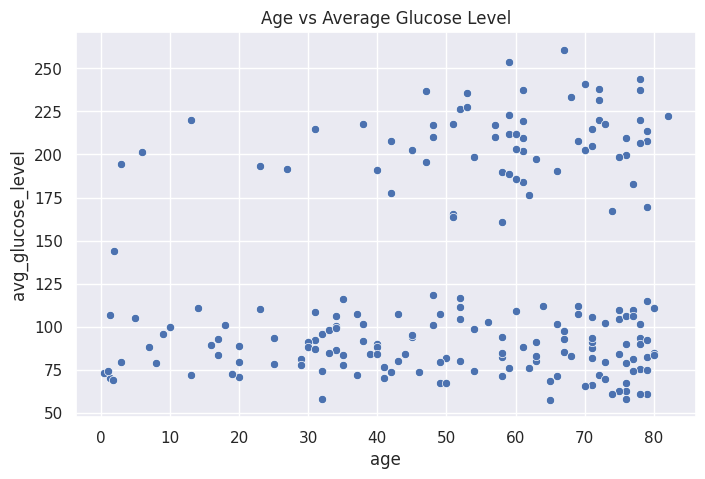

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='avg_glucose_level', data=df)
plt.title("Age vs Average Glucose Level")
plt.show()

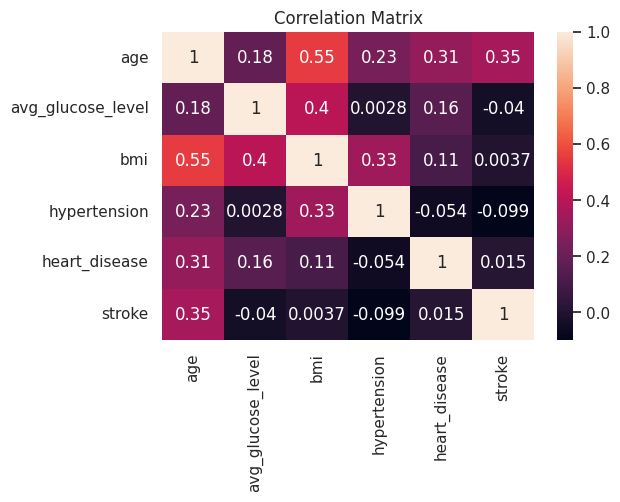

In [31]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','avg_glucose_level','bmi','hypertension','heart_disease','stroke']].corr(),
            annot=True)
plt.title("Correlation Matrix")
plt.show()